# Learning-to-Rank using CatboostRanker

CatBoost Ranker is designed specifically for ranking tasks, where the goal is to order items by relevance rather than predict exact values. It calculates the loss by pairing two samples via [Pairwise metrics](https://catboost.ai/docs/en/concepts/loss-functions-ranking), which considers one the winner whereas the other the loser. Here, we show the example of CatboostRankerMother, customised CatboostRanker wrapper integrated with Mother pipeline. 

Imports needed for the tutorial

In [16]:
import pandas as pd

from sklearn import pipeline as sklearn_pipeline
from sklearn.model_selection import KFold, train_test_split, cross_validate, GroupKFold
import matplotlib.pyplot as plt
from catboost import Pool, cv

import mother.ml as ml
import mother.pipeline_utils as mother_takes_care
from mother import cv as cv_module
from mother import feature_generation as fg
from mother.ml import CatboostRankerMother, avg_ndcg_score
from mother.preprocessing import SmilesToMolTransformer, StandardizerTransformer
import mother.optimization as opt
from sklearn import set_config
import numpy as np
from sklearn.metrics import make_scorer
from pathlib import Path

Loading test dataset and performing initial preparation steps to modify the test dataset for this demo.

In [17]:
input_file: Path = Path("../freesolv_train.csv")
data: pd.DataFrame = pd.read_csv(input_file, sep=",")
# Removing rows where 'cat_code' is NaN

# Ensure 'iupac' column exists before dropping it
if "iupac" in data.columns:
    data = data.drop(columns=["iupac", "calc", "float_col", "cat_col"])

data = data.rename(columns={"int_col": "groups_to_rank"})

data = data.head(100)  # limit data to 100 rows for testing
data = pd.concat(
    [
        data.assign(rankable_condition="A", expt=data["expt"] + 2),
        data.assign(rankable_condition="B", expt=data["expt"] + 1),
        data.assign(rankable_condition="C", expt=data["expt"]),
    ],
    ignore_index=True,
)
data = data.sort_values(by="groups_to_rank", ascending=True).reset_index(drop=True)
data = data.dropna(subset=["groups_to_rank"])

data["expt"] = data["expt"] * (1 + np.random.randn(len(data)) * 0.2)

data["expt"] = data["expt"] - data["expt"].min() + 1

data

,smiles,expt,groups_to_rank,rankable_condition
0,CN(C)C(=O)c1ccc(cc1)OC,21.774479,1.0,A
1,CN(C)C(=O)c1ccc(cc1)OC,23.074273,1.0,B
2,CN(C)C(=O)c1ccc(cc1)OC,21.881941,1.0,C
3,CS(=O)(=O)Cl,31.658640,2.0,B
4,CS(=O)(=O)Cl,29.400478,2.0,C
...,...,...,...,...
142,CCCNCCC,32.662879,49.0,A
143,CCCNCCC,32.355157,49.0,B
144,c1ccc(cc1)N,30.150676,50.0,B
145,c1ccc(cc1)N,30.985406,50.0,A


Pre-process the smiles data using an sklearn pipeline. The resulting data is a mol formatted pandas dataframe



In [18]:
preprocessor: sklearn_pipeline.Pipeline = sklearn_pipeline.Pipeline(
    [
        (
            "smiles_standardizer",
            StandardizerTransformer(flags=["STANDARDIZE", "NEUTRALIZE", "DESALT"]),
        ),
        ("smiles_to_mol", SmilesToMolTransformer()),
        # Add other column transformations here if needed
    ],
    memory=None,
).set_output(transform="pandas")
groups_engine = cv_module.TanimotoGroupingFromMols(similarity_threshold=0.1)

The code in the following cell defines the grouping strategy for cross-validation using Tanimoto similarity. It utilizes the `TanimotoGroupingFromMols` class from the `mother.cv.core` module to group molecules based on their structural similarity. The similarity threshold is set to 0.3. The resulting groups are transformed into a pandas DataFrame, where each molecule is assigned a "tanimoto-group" identifier. These groups are then used as the "groups" parameter in sklearn's cross-validation methods, such as `GroupKFold`. The code also prints the number of unique Tanimoto groups and converts the group identifiers into categorical codes for further processing.

In [19]:
structure_data: pd.Series = data["smiles"]
mol_data: pd.DataFrame = preprocessor.fit_transform(structure_data)

# cv grouping

# Apply the preprocessor and Tanimoto grouping to the unique SMILES
mol_data = preprocessor.fit_transform(structure_data)
cv_groups = groups_engine.set_output(transform="pandas").fit_transform(mol_data.iloc[:, 0])
# Ensure no NaN values in the Tanimoto group column
print(f"{cv_groups['tanimoto-group'].nunique()} different Tanimoto groups (to be used for cross-validation) found.")
# Merge the Tanimoto groups with the original data
data = data.reset_index(drop=True).join(cv_groups.reset_index(drop=True))
data

[12:47:34] Initializing Normalizer
[12:47:34] Initializing Normalizer
[12:47:34] Initializing MetalDisconnector
[12:47:34] Initializing Normalizer
[12:47:35] Initializing Normalizer
[12:47:35] Initializing Normalizer
[12:47:35] Initializing MetalDisconnector
[12:47:35] Initializing Normalizer


10 different Tanimoto groups (to be used for cross-validation) found.


,smiles,expt,groups_to_rank,rankable_condition,tanimoto-group
0,CN(C)C(=O)c1ccc(cc1)OC,21.774479,1.0,A,0.0
1,CN(C)C(=O)c1ccc(cc1)OC,23.074273,1.0,B,0.0
2,CN(C)C(=O)c1ccc(cc1)OC,21.881941,1.0,C,0.0
3,CS(=O)(=O)Cl,31.658640,2.0,B,1.0
4,CS(=O)(=O)Cl,29.400478,2.0,C,1.0
...,...,...,...,...,...
142,CCCNCCC,32.662879,49.0,A,7.0
143,CCCNCCC,32.355157,49.0,B,7.0
144,c1ccc(cc1)N,30.150676,50.0,B,5.0
145,c1ccc(cc1)N,30.985406,50.0,A,5.0


Create a feature generator that prepares the previously formatted mol dataframe




In [20]:
feature_generator = sklearn_pipeline.FeatureUnion(
    transformer_list=[
        ("maccs", fg.MaccsFingerprints()),
        ("morgan", fg.MorganFingerprints()),
        ("desc", fg.ChemicalDescriptors()),
    ]
).set_output(transform="pandas")


features: pd.DataFrame = feature_generator.fit_transform(mol_data["Molecule"])
# add features to the data
data = data.join(features)
# drop the original smiles column
# data = data.drop(columns=["smiles"])#

### Mother CatBoost Ranker

The **Mother CatBoost Ranker** is a ranking model built on CatBoost, enhanced by the `mother` library for group-based ranking tasks.


#### Workflow:
1. **Data Preparation**: Prepare the following components:

   a. **Features (`X`)**: The input features for the model, excluding the ranking group column (`groups_to_rank`). These features include both numerical and categorical data, as well as the generated molecular descriptors and fingerprints.

   b. **Labels (`y`)**: The target variable (`expt`) that the model is trained to predict.

   c. **Categorical Features**: The list of categorical features (`categoric_features`), which in this case includes `rankable_condition`.

   d. **Group IDs**: The ranking group column (`groups_to_rank`) is used as the `group_string` parameter in the `Pool`. This ensures that the ranking model respects the group structure during training and evaluation. 
2. **Pipeline Setup**: Use `PipelineWithHyperparameterRooting` to integrate preprocessing, feature generation, and ranking model.
3. **Training & Evaluation**: Train with `fit` and evaluate using metrics like NDCG via cross-validation.

The Mother CatBoost Ranker is ideal for grouped data tasks like molecular ranking, search relevance, and recommendations.


In [21]:
ranking_groups = "groups_to_rank"
categoric_features = ["rankable_condition"]

data = data.sort_values(by=[ranking_groups]).reset_index(drop=True)
X = data.drop(columns=["expt"])
y = data["expt"]
# Convert group_id to an integral type
X[ranking_groups] = X[ranking_groups].astype(int)

#### Defining the Mother CatBoost Ranker Pipeline

We can use the utility function 'get_ranking_pipeline' to create the pipeline, comprising of a conventional feature selection step followed by the CatBoost ranking model.
A few settings are automatically carried out, by calling this:

- *Metadata Routing*:  
The `set_config(enable_metadata_routing=True)` command enables metadata routing in scikit-learn. Metadata routing allows for the seamless flow of additional information (e.g., group IDs, sample weights) through the pipeline, ensuring that all components can access the necessary metadata during training and evaluation.
- *Scoring Function*:  
The tuner is set up with a custom scoring function `avg_ndcg_scorer`, which is designed to evaluate the ranking performance of the model using the Average Normalized Discounted Cumulative Gain (NDCG) metric. This scorer takes into account the group structure of the data, ensuring that the evaluation is meaningful for ranking tasks. 

Note: The `group_id` parameter needs to be passed to the 'fit' method of the pipeline, as shown later in the code.



In [22]:
mother_cat_rank_pipeline, tuner = mother_takes_care.get_ranking_pipeline(
    categorical_features=categoric_features,
    k_scorer=6,
    target_type="single_target",  # only option currently
    model_kwargs={"logging_level": "Silent"},
)

No cv strategy was passed, using the RepeatedKfold (n_repeats=3, n_splits=3, random_state=42)
/workspaces/mother-ml/.venv/lib/python3.11/site-packages/optuna/_experimental.py:32: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
/workspaces/mother-ml/.venv/lib/python3.11/site-packages/optuna/_experimental.py:32: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  warnings.warn(
/workspaces/mother-ml/.venv/lib/python3.11/site-packages/optuna/_experimental.py:32: ExperimentalWarning: Argument ``constant_liar`` is an experimental feature. The interface can change in the future.
  warnings.warn(


We can also include another scoring method "precision" which we will use later for our analysis.

In [23]:
def precision_score(y_true_group, y_pred_group, k=3):
    """
    Calculate the precision score for a given group.

    Parameters:
    y_true_group (pd.Series): True target values for the group.
    y_pred_group (pd.Series): Predicted target values for the group.
    k (int): Number of top elements to consider.

    Returns:
    float: Precision score.
    """
    top_k_pred = y_pred_group.nlargest(k).index
    top_k_true = y_true_group.nlargest(k).index
    true_positives = len(set(top_k_pred).intersection(set(top_k_true)))
    return true_positives / k

### Simplest Case: Fit and Predict on the Same Data

Training and testing on the same data using `fit` and `predict` is quick but unreliable. It risks overfitting and provides overly optimistic metrics, failing to reflect real-world performance. Cross-validation or a separate test set is recommended for robust evaluation.


In [24]:
# Fit the model to the data
mother_cat_rank_pipeline.fit(
    X=X.drop(columns=[ranking_groups, "tanimoto-group", "smiles"]), y=y, group_id=X[ranking_groups]
)

# Predict targets
targets_pred = mother_cat_rank_pipeline.predict(X.drop(columns=[ranking_groups, "tanimoto-group", "smiles"]))

### Visualising Ranking Results
To visualize the ranking results, you can create a plot that shows the predicted ranking positions for each group. This allows you to assess how well the model has ranked the items within each group and identify any discrepancies or patterns in the ranking.

For example, you can use a scatter plot where the x-axis represents the true ranking positions (or group IDs) and the y-axis represents the predicted ranking positions. This visualization helps in understanding the alignment between the true and predicted rankings, as well as identifying any outliers or inconsistencies.

In [25]:
# Add predictions to the data
data["predicted_expt"] = targets_pred

# Group by ranking groups and rank the predictions
data["predicted_rank"] = data.groupby(ranking_groups)["predicted_expt"].rank(ascending=False)

data[["groups_to_rank", "predicted_expt", "predicted_rank", "rankable_condition"]]

,groups_to_rank,predicted_expt,predicted_rank,rankable_condition
0,1.0,-10.043097,3.0,A
1,1.0,14.137115,1.0,B
2,1.0,0.423023,2.0,C
3,2.0,11.653076,1.0,B
4,2.0,-13.351583,3.0,C
...,...,...,...,...
142,49.0,13.429029,1.0,A
143,49.0,0.484454,2.0,B
144,50.0,0.179325,2.0,B
145,50.0,14.044130,1.0,A


Mean NDCG Score: 1.0000
Mean Precision Score k=1: 1.0000
Mean Precision Score k=3: 1.0000


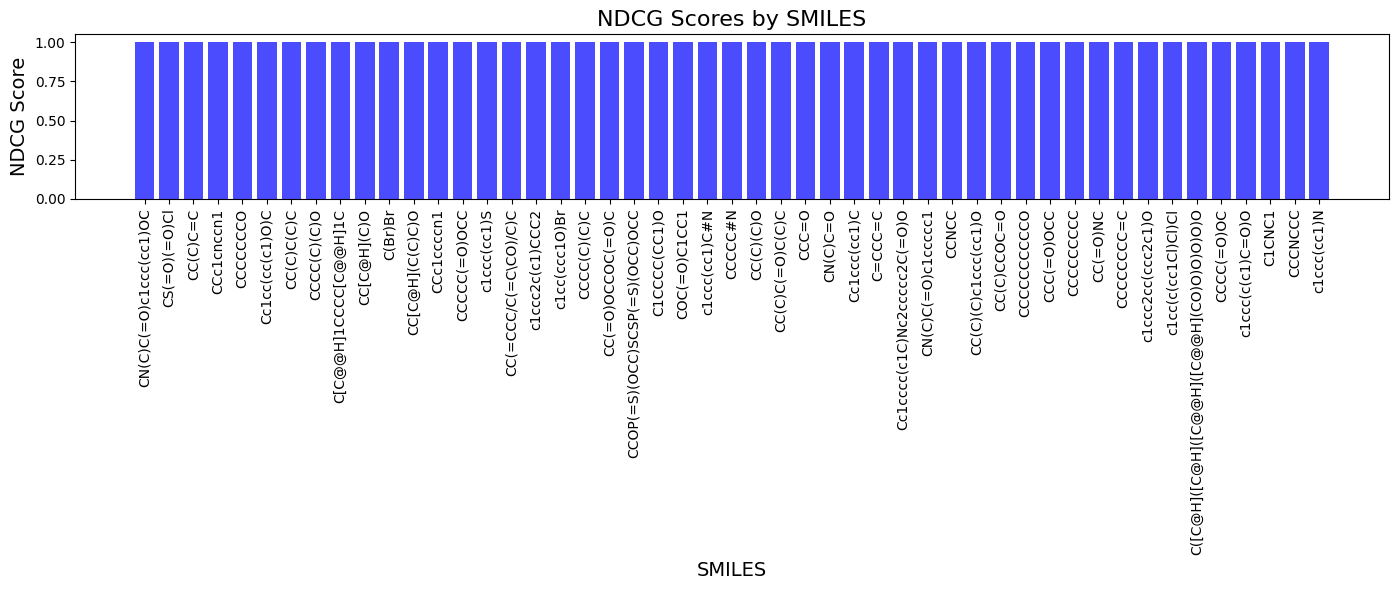

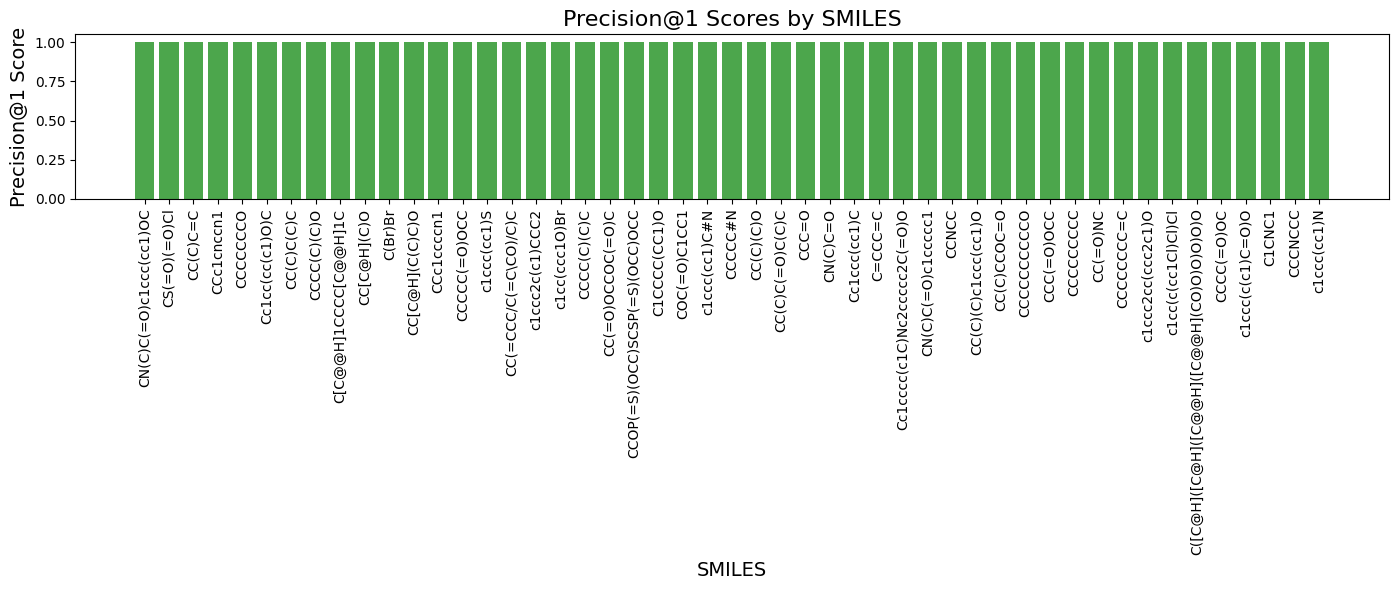

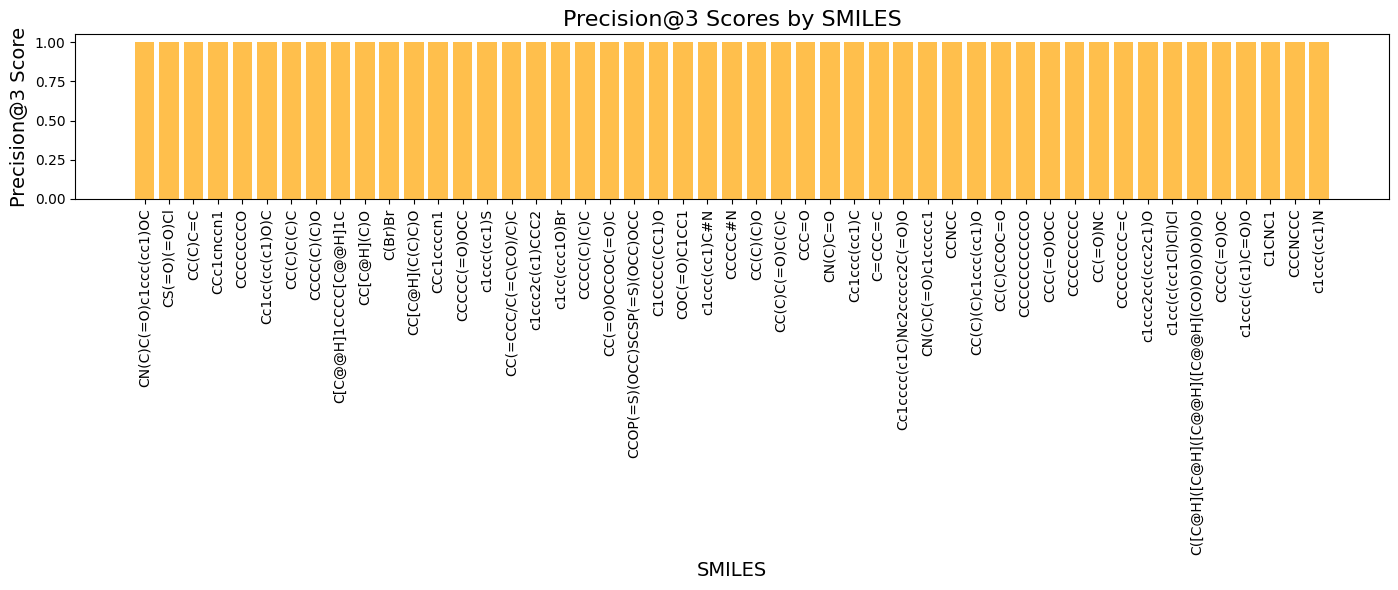

Ranking performance evaluation completed.


In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import ndcg_score


def plot_metrics_individual(features, ndcg_scores, precision_scores_1, precision_scores_3):
    """
    Plot NDCG and Precision scores for each SMILES.

    Parameters:
    features (pd.DataFrame): DataFrame containing feature information including SMILES.
    ndcg_scores (list): List of NDCG scores for each SMILES.
    precision_scores_1 (list): List of Precision@1 scores for each SMILES.
    precision_scores_3 (list): List of Precision@3 scores for each SMILES.
    """
    unique_ingredients = features["smiles"].unique()

    # Plot NDCG Scores
    plt.figure(figsize=(14, 6))
    plt.bar(unique_ingredients, ndcg_scores, color="blue", alpha=0.7)
    plt.title("NDCG Scores by SMILES", fontsize=16)
    plt.xlabel("SMILES", fontsize=14)
    plt.ylabel("NDCG Score", fontsize=14)
    plt.xticks(rotation=90, fontsize=10)
    plt.tight_layout()
    plt.show()

    # Plot Precision@1 Scores
    plt.figure(figsize=(14, 6))
    plt.bar(unique_ingredients, precision_scores_1, color="green", alpha=0.7)
    plt.title("Precision@1 Scores by SMILES", fontsize=16)
    plt.xlabel("SMILES", fontsize=14)
    plt.ylabel("Precision@1 Score", fontsize=14)
    plt.xticks(rotation=90, fontsize=10)
    plt.tight_layout()
    plt.show()

    # Plot Precision@3 Scores
    plt.figure(figsize=(14, 6))
    plt.bar(unique_ingredients, precision_scores_3, color="orange", alpha=0.7)
    plt.title("Precision@3 Scores by SMILES", fontsize=16)
    plt.xlabel("SMILES", fontsize=14)
    plt.ylabel("Precision@3 Score", fontsize=14)
    plt.xticks(rotation=90, fontsize=10)
    plt.tight_layout()
    plt.show()


def evaluate_ranking_performance(y_true, y_pred, features, group_string="group_id"):
    """
    Evaluate the ranking performance using Normalized Discounted Cumulative Gain (NDCG) and Precision.

    Parameters:
    y_true (np.ndarray): True target values.
    y_pred (np.ndarray): Predicted target values.
    features (pd.DataFrame): DataFrame containing feature information including group_string.

    Returns:
    float: NDCG score.
    """
    y_true = y_true.reset_index(drop=True)
    y_pred = pd.Series(y_pred).reset_index(drop=True)
    ndcg_scores = []
    precision_scores_1 = []
    precision_scores_3 = []

    unique_groups = features[group_string].unique()
    for group in unique_groups:
        group_indices = features[features[group_string] == group].index
        y_true_group = y_true[group_indices]
        y_pred_group = y_pred[group_indices]

        if len(y_true_group) > 1:  # NDCG is not defined for groups with a single item
            ndcg = ndcg_score([y_true_group], [y_pred_group], k=3)
            ndcg_scores.append(ndcg)

            precision_1 = precision_score(y_true_group, y_pred_group, 1)
            precision_scores_1.append(precision_1)
            precision_3 = precision_score(y_true_group, y_pred_group, 3)
            precision_scores_3.append(precision_3)

            # Add metrics to the features DataFrame
            features.loc[group_indices, "ndcg_score"] = ndcg
            features.loc[group_indices, "precision_score_k1"] = precision_1
            features.loc[group_indices, "precision_score_k3"] = precision_3

    mean_ndcg = np.mean(ndcg_scores)
    mean_precision_1 = np.mean(precision_scores_1)
    mean_precision_3 = np.mean(precision_scores_3)

    print(f"Mean NDCG Score: {mean_ndcg:.4f}")
    print(f"Mean Precision Score k=1: {mean_precision_1:.4f}")
    print(f"Mean Precision Score k=3: {mean_precision_3:.4f}")
    # Call the function to plot metrics by group
    plot_metrics_individual(features, ndcg_scores, precision_scores_1, precision_scores_3)
    return {
        "mean_ndcg": mean_ndcg,
        "mean_precision_1": mean_precision_1,
        "mean_precision_3": mean_precision_3,
    }


# Evaluate the ranking performance
ranking_performance = evaluate_ranking_performance(y, targets_pred, X, group_string=ranking_groups)
print("Ranking performance evaluation completed.")

<Figure size 2000x600 with 0 Axes>

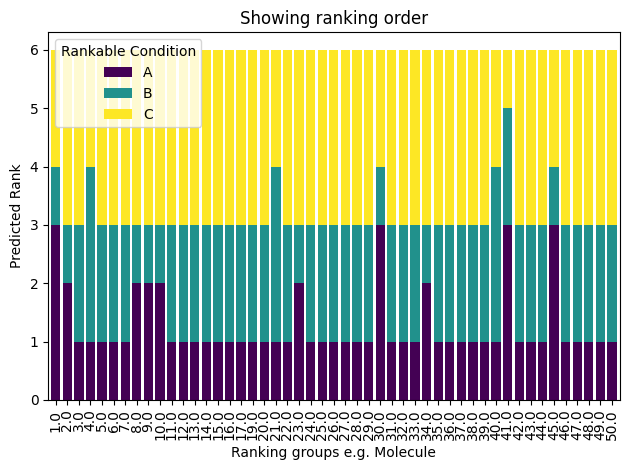

In [27]:
import seaborn as sns

sorted_data = data.sort_values(by=["groups_to_rank", "predicted_rank"]).reset_index(drop=True)

# Pivot the data to create separate columns for each rankable_condition based on predicted_rank
pivot_data = sorted_data.pivot_table(
    index="groups_to_rank", columns="rankable_condition", values="predicted_rank", aggfunc="mean"
).fillna(0)

# Create a stacked bar chart
plt.figure(figsize=(20, 6))
pivot_data.plot(kind="bar", stacked=True, colormap="viridis", width=0.8)

# Set plot title and labels
plt.title("Showing ranking order")
plt.xlabel("Ranking groups e.g. Molecule")
plt.ylabel("Predicted Rank")
plt.xticks(rotation=90)
plt.legend(title="Rankable Condition")
plt.tight_layout()

#### Cross-Validation Pooling

For Group K fold cross-validation, the entries will be separated according to tanimoto groups.

Note 1: When performing cross validation, if the number of groups is greater than the number of folds (n_splits), resulting folds will contain more than one group and will be treated as belonging to the same group

Note 2: The Tanimoto groups are only to be used as the "groups" parameter of sklearn's cross-validation methods (cross_val_score, cross_validate) and are NOT to be interchangeable with the previously created ranking groups. Ranking groups are to be used for generating ranking queries. When working with (Mother)CatBoostRanker models, ranking groups are to be passed as the "group_id" parameter.


### Importance of Group Control in Cross-Validation

Depending on the use case, it might be crucial to have tight control over which groups are included in each fold during cross-validation. This is particularly important when working with datasets where certain groups of data points share inherent similarities, such as molecular structures or time-series data. Without proper handling, the model might inadvertently learn patterns specific to certain groups, leading to overfitting and overly optimistic performance metrics.



### Cross-Validation example using chemical similarity

To ensure that the cross-validation process respects the chemical similarity of molecules, we utilize Tanimoto similarity-based grouping. This approach ensures that molecules with similar chemical structures are grouped together, preventing data leakage and providing a more realistic evaluation of the model's performance.

#### Steps:
1. **Tanimoto Grouping**: Molecules are grouped based on their Tanimoto similarity using the `TanimotoGroupingFromMols` class. A similarity threshold of 0.3 is used to define the groups.
2. **Group Assignment**: Each molecule is assigned a "tanimoto-group" identifier, which is then used as the `groups` parameter in cross-validation methods.
3. **Group K-Fold Cross-Validation**: The `GroupKFold` method is employed to split the data into folds, ensuring that all molecules within the same Tanimoto group are kept in the same fold.

This method provides a robust framework for evaluating the model while accounting for the inherent chemical similarities in the dataset.


In [28]:
# Ensure combined_groups matches the length of data
combined_groups = list(zip(data["tanimoto-group"], data[ranking_groups]))

# Reset the index of X and y to ensure alignment
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

# Initialize GroupKFold with the desired number of splits
cv = GroupKFold(n_splits=5)

In [ ]:
# Extract group codes for cross-validation
cv_groupcodes = X["tanimoto-group"].values


model_tuned = tuner.optimize(
    mother_cat_rank_pipeline,
    X.drop(columns=["groups_to_rank", "tanimoto-group", "smiles"]),
    data["expt"],
    cv,
    groups=X["tanimoto-group"],
    hyperparameter_space_function=lambda trial, X, y: {
        "model__learning_rate": trial.suggest_float("ml_model__learning_rate", 0.01, 0.3, log=True),
        "model__l2_leaf_reg": trial.suggest_float("ml_model__l2_leaf_reg", 1, 10),
        "model__random_strength": trial.suggest_float("ml_model__random_strength", 1, 10),
    },
    ranking_groups=X["groups_to_rank"].values,
)

In [ ]:
print(f"Best Parameters:")
print(tuner.study.best_trial.params)
print("Best Score:")
print(tuner.study.best_value)